### Imports

In [45]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.isdir(os.path.join(os.getcwd(), 'ppi_py')):
    repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from ppi_py import ppi_mean_ci


### Load treecover dataset

Number of rows: 67968
Number of clusters: 3415
Cluster sizes (rows per cluster) - min: 1, mean: 19.90, q1: 13.0, median: 21.0, q3: 27.0, max: 48
Dataset loaded. Sample size: 67968


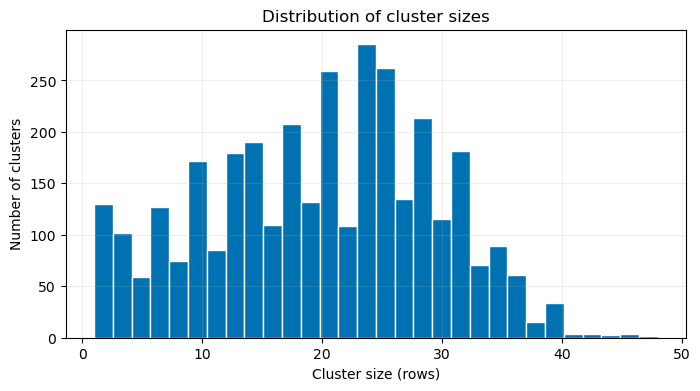

,ClusterID,Treecover,Population,Treecover_hat,Population_hat
0,485.0,0.000000,0.290985,0.000000,0.223613
1,1689.0,0.000000,0.070059,0.000000,1.089495
2,3637.0,32.511176,1.771785,42.111039,2.923414
3,2193.0,1.706111,2.654329,0.000000,0.872536
4,2607.0,34.121974,1.539581,38.179145,1.788519


In [46]:
dataset_path = os.path.join(repo_root, 'examples', 'data', 'kluger_treecover.npz')
data = np.load(dataset_path, allow_pickle=False)

df = pd.DataFrame({
    'ClusterID': data['TreecoverFormatted__ClusterIDs'],
    'Treecover': data['TreecoverFormatted__GoodDat__Treecover'],
    'Population': data['TreecoverFormatted__GoodDat__Population'],
    'Treecover_hat': data['TreecoverFormatted__ProxyDat__Treecover'],
    'Population_hat': data['TreecoverFormatted__ProxyDat__Population'],
})

cluster_sizes = df.groupby('ClusterID').size()
q1 = cluster_sizes.quantile(0.25)
q3 = cluster_sizes.quantile(0.75)

print('Number of rows:', df.shape[0])
print('Number of clusters:', df['ClusterID'].nunique())
print(
    'Cluster sizes (rows per cluster) - '
    f"min: {cluster_sizes.min()}, mean: {cluster_sizes.mean():.2f}, "
    f"q1: {q1:.1f}, median: {cluster_sizes.median():.1f}, q3: {q3:.1f}, "
    f"max: {cluster_sizes.max()}"
)
print(f'Dataset loaded. Sample size: {len(df)}')

plt.figure(figsize=(8, 4))
plt.hist(cluster_sizes, bins=30, color='#0072B2', edgecolor='white')
plt.xlabel('Cluster size (rows)')
plt.ylabel('Number of clusters')
plt.title('Distribution of cluster sizes')
plt.grid(alpha=0.2)
plt.show()

df.head()


### True Parameter (Full Data Mean)

In [47]:
true_mean = df[['Treecover', 'Population']].mean().to_numpy()

print(f'True mean (Treecover): {true_mean[0]:.6f}')
print(f'True mean (Population): {true_mean[1]:.6f}')


True mean (Treecover): 26.571563
True mean (Population): 1.751204


### Coverage Simulation

In [48]:
alpha = 0.05
n_clusters = 100
K = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 10.0]
reps = 500
rng = np.random.default_rng(2026)

print('n_clusters =', n_clusters)
print('K =', K)
print('reps =', reps)


n_clusters = 100
K = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 10.0]
reps = 500


In [49]:
def one_draw_coverage(df, true_mean, n_clusters, k, alpha, rng):
    cluster_ids = df['ClusterID'].unique()
    n_unlabeled_clusters = int(round(k * n_clusters))

    labeled_ids = rng.choice(cluster_ids, size=n_clusters, replace=False)
    remaining_ids = cluster_ids[~np.isin(cluster_ids, labeled_ids)]

    if n_unlabeled_clusters > len(remaining_ids):
        raise ValueError('Not enough remaining clusters for the unlabeled set.')

    unlabeled_ids = rng.choice(
        remaining_ids,
        size=n_unlabeled_clusters,
        replace=False,
    )

    labeled = df[df['ClusterID'].isin(labeled_ids)].copy()
    unlabeled = df[df['ClusterID'].isin(unlabeled_ids)].copy()

    Y = labeled[['Treecover', 'Population']].to_numpy()
    Yhat = labeled[['Treecover_hat', 'Population_hat']].to_numpy()
    Yhat_unlabeled = unlabeled[['Treecover_hat', 'Population_hat']].to_numpy()

    group = pd.factorize(labeled['ClusterID'], sort=False)[0]
    group_unlabeled = pd.factorize(unlabeled['ClusterID'], sort=False)[0]

    lower_cluster, upper_cluster = ppi_mean_ci(
        Y,
        Yhat,
        Yhat_unlabeled,
        alpha=alpha,
        lam=None,
        group=group,
        group_unlabeled=group_unlabeled,
        lam_optim_mode='element',
    )

    lower_no, upper_no = ppi_mean_ci(
        Y,
        Yhat,
        Yhat_unlabeled,
        alpha=alpha,
        lam=None,
        lam_optim_mode='element',
    )

    cover_tree_cluster = (lower_cluster[0] <= true_mean[0]) and (true_mean[0] <= upper_cluster[0])
    cover_tree_no = (lower_no[0] <= true_mean[0]) and (true_mean[0] <= upper_no[0])
    cover_population_cluster = (lower_cluster[1] <= true_mean[1]) and (true_mean[1] <= upper_cluster[1])
    cover_population_no = (lower_no[1] <= true_mean[1]) and (true_mean[1] <= upper_no[1])

    return cover_tree_cluster, cover_tree_no, cover_population_cluster, cover_population_no


In [50]:
tree_cluster, tree_no, population_cluster, population_no = one_draw_coverage(
    df,
    true_mean,
    n_clusters,
    1.0,
    alpha,
    rng,
)

print('Single draw check (K=1) - Treecover with clusters:', tree_cluster)
print('Single draw check (K=1) - Treecover without clusters:', tree_no)
print('Single draw check (K=1) - Population with clusters:', population_cluster)
print('Single draw check (K=1) - Population without clusters:', population_no)


Single draw check (K=1) - Treecover with clusters: True
Single draw check (K=1) - Treecover without clusters: False
Single draw check (K=1) - Population with clusters: True
Single draw check (K=1) - Population without clusters: True


In [51]:
rows = []

for k in K:
    cover_tree_cluster_vals = []
    cover_tree_no_vals = []
    cover_population_cluster_vals = []
    cover_population_no_vals = []

    for _ in range(reps):
        tree_cluster, tree_no, population_cluster, population_no = one_draw_coverage(
            df,
            true_mean,
            n_clusters,
            k,
            alpha,
            rng,
        )
        cover_tree_cluster_vals.append(tree_cluster)
        cover_tree_no_vals.append(tree_no)
        cover_population_cluster_vals.append(population_cluster)
        cover_population_no_vals.append(population_no)

    rows.append({
        'K': k,
        'target': 'Treecover',
        'coverage_cluster': np.mean(cover_tree_cluster_vals),
        'coverage_no_cluster': np.mean(cover_tree_no_vals),
    })
    rows.append({
        'K': k,
        'target': 'Population',
        'coverage_cluster': np.mean(cover_population_cluster_vals),
        'coverage_no_cluster': np.mean(cover_population_no_vals),
    })

coverage_results = pd.DataFrame(rows)
coverage_results


,K,target,coverage_cluster,coverage_no_cluster
0,0.25,Treecover,0.930,0.366
1,0.25,Population,0.938,0.398
2,0.50,Treecover,0.938,0.348
3,0.50,Population,0.916,0.434
4,0.75,Treecover,0.962,0.338
5,0.75,Population,0.960,0.444
6,1.00,Treecover,0.954,0.396
7,1.00,Population,0.940,0.472
8,2.00,Treecover,0.954,0.344
9,2.00,Population,0.946,0.456


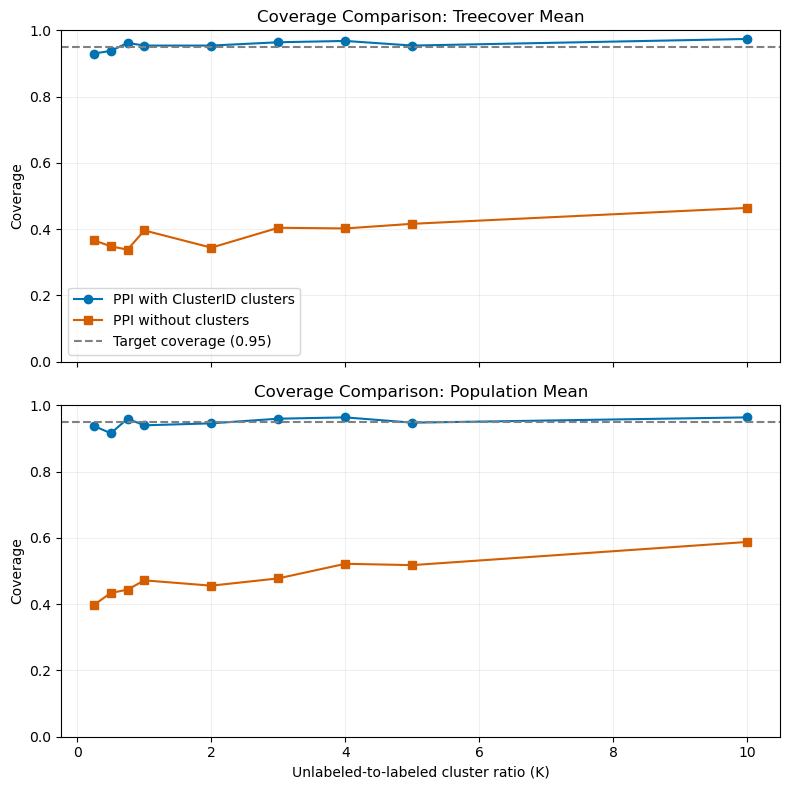

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for ax, target in zip(axes, ['Treecover', 'Population']):
    plot_df = coverage_results[coverage_results['target'] == target]

    ax.plot(
        plot_df['K'],
        plot_df['coverage_cluster'],
        marker='o',
        color='#0072B2',
        label='PPI with ClusterID clusters',
    )
    ax.plot(
        plot_df['K'],
        plot_df['coverage_no_cluster'],
        marker='s',
        color='#D55E00',
        label='PPI without clusters',
    )
    ax.axhline(0.95, linestyle='--', color='gray', label='Target coverage (0.95)')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Coverage')
    ax.set_title(f'Coverage Comparison: {target} Mean')
    ax.grid(alpha=0.2)

axes[0].legend()
axes[1].set_xlabel('Unlabeled-to-labeled cluster ratio (K)')
plt.tight_layout()
plt.show()
